# Premier tests

In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA A100 80GB PCIe


In [106]:
from transformers import AutoConfig

config = AutoConfig.from_pretrained("HuggingFaceTB/SmolLM3-3B")
print(config.hidden_size)
print(config.num_attention_heads)
print(config.num_hidden_layers)

2048
16
36


## Avec vllm pour l'inférence

- dtype:"bfloat16" : 
    - Brain Float 16 : moitier mem que float32 , même range dynamique
    - 2 byte / param -> 3B*2 ~ 6 gb
- gpu_memory_utilization=0.1 : limite l'utilisation du gpu à 10% ~ 8gb
- max_model_len=4096 : limite la taille des buffers du KV cache

In [ ]:
from vllm import LLM, SamplingParams

llm = LLM(
    model="HuggingFaceTB/SmolLM3-3B",
    dtype="bfloat16",
    gpu_memory_utilization=0.1,
    max_model_len=4096
)

INFO 03-04 09:22:51 [utils.py:223] non-default args: {'dtype': 'bfloat16', 'max_model_len': 4096, 'gpu_memory_utilization': 0.1, 'disable_log_stats': True, 'model': 'HuggingFaceTB/SmolLM3-3B'}
INFO 03-04 09:22:52 [model.py:529] Resolved architecture: SmolLM3ForCausalLM
INFO 03-04 09:22:52 [model.py:1549] Using max model len 4096
INFO 03-04 09:22:52 [scheduler.py:224] Chunked prefill is enabled with max_num_batched_tokens=8192.
(EngineCore_DP0 pid=2409702) INFO 03-04 09:22:53 [core.py:97] Initializing a V1 LLM engine (v0.16.0) with config: model='HuggingFaceTB/SmolLM3-3B', speculative_config=None, tokenizer='HuggingFaceTB/SmolLM3-3B', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=4096, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, enable_return_routed_ex

Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]


(EngineCore_DP0 pid=2409702) INFO 03-04 09:23:39 [default_loader.py:293] Loading weights took 34.34 seconds
(EngineCore_DP0 pid=2409702) INFO 03-04 09:23:40 [gpu_model_runner.py:4221] Model loading took 5.83 GiB memory and 39.335521 seconds
(EngineCore_DP0 pid=2409702) INFO 03-04 09:23:55 [backends.py:916] Using cache directory: /home/thomas/.cache/vllm/torch_compile_cache/681b965a0c/rank_0_0/backbone for vLLM's torch.compile
(EngineCore_DP0 pid=2409702) INFO 03-04 09:23:55 [backends.py:976] Dynamo bytecode transform time: 13.83 s
(EngineCore_DP0 pid=2409702) INFO 03-04 09:24:00 [backends.py:351] Cache the graph of compile range (1, 8192) for later use
(EngineCore_DP0 pid=2409702) INFO 03-04 09:24:04 [backends.py:368] Compiling a graph for compile range (1, 8192) takes 4.44 s
(EngineCore_DP0 pid=2409702) INFO 03-04 09:24:04 [monitor.py:34] torch.compile takes 18.28 s in total
(EngineCore_DP0 pid=2409702) INFO 03-04 09:24:06 [gpu_worker.py:373] Available KV cache memory: 0.85 GiB
(Engin

Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 51/51 [00:03<00:00, 13.81it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 35/35 [00:02<00:00, 16.53it/s]


(EngineCore_DP0 pid=2409702) INFO 03-04 09:24:13 [gpu_model_runner.py:5246] Graph capturing finished in 7 secs, took 0.71 GiB
(EngineCore_DP0 pid=2409702) INFO 03-04 09:24:13 [core.py:278] init engine (profile, create kv cache, warmup model) took 32.35 seconds
INFO 03-04 09:24:14 [llm.py:355] Supported tasks: ['generate']


In [12]:
params = SamplingParams(temperature=0.8, top_p=0.95, max_tokens=200)


In [ ]:
prompt = "What is the capital of France ? The first word of your response should be the answer"
outputs = llm.generate(prompt, params)

print(outputs[0].outputs[0].text)

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

, and the response should include the location of the capital within the country.

The capital of France is Paris, which is located in Île-de-France region.


In [28]:
print(outputs[0].outputs[0].finish_reason)

stop


## Avec AutoModelCausalLM pour l'inférence

In [1]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model_name = "HuggingFaceTB/SmolLM3-3B"
device = "cuda"  # for GPU usage or "cpu" for CPU usage

# load the tokenizer and the model
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [2]:
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.bfloat16 
).to(device)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [ ]:
# prepare the model input
prompt = "What is the capital of France ?"
messages = [
    {"role": "system", "content":"Answer with one word./no_think"},
    #{"role": "system", "content":"Speak like a pirat./no_think"},
    {"role": "user", "content": prompt}
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=False
)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)


In [28]:
# Generate the output
generated_ids = model.generate(**model_inputs, max_new_tokens=100)

# Get and decode the output
output_ids = generated_ids[0][len(model_inputs.input_ids[0]) :]
print(tokenizer.decode(output_ids, skip_special_tokens=True))


Arr, me hearty! The capital o' France be Paris, a grand city with lots o' history and beauty!


## Test : récupérer les hidden states du modèle, voir à partir de quelle couche la réponse apparait

In [1]:
def remove_skiplines(stri):
    return stri.replace("\n","\\n")

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model_name = "HuggingFaceTB/SmolLM3-3B"
device = "cuda"  # for GPU usage or "cpu" for CPU usage

# load the tokenizer and the model
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.bfloat16 
).to(device)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

SmolLM utilise le flag /no_think pour désactiver le mode réflexion long

In [3]:
# prepare the model input
prompt = "The capital of Germany is"
prompt2 = "The capital of France is"
messages = [
    {"role": "system", "content":"Answer with one word./no_think"},
    {"role": "user", "content": prompt2}
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=False
)
inputs = tokenizer([text], return_tensors="pt").to(model.device)

In [4]:
with torch.no_grad():
    outputs = model(
        **inputs,
        output_hidden_states=True,
    )   

hidden_states = outputs.hidden_states

In [5]:
layer_pos = 36
layer_hidden = hidden_states[layer_pos]     # (batch, seq_len, hidden)
last_token_hidden = layer_hidden[:, -1, :]  # keep the last token (-1) of each prompt (:) for all hidden dimensions (2nd :)

# Apply final layer norm if model has one
if hasattr(model, "model") and hasattr(model.model, "norm"):
    last_token_hidden = model.model.norm(last_token_hidden)

# Project to vocab
logits = model.lm_head(last_token_hidden)

probs = torch.softmax(logits, dim=-1)
top_token_id = torch.argmax(probs, dim=-1)
top_token = tokenizer.decode(top_token_id)
print(top_token)

Paris


In [6]:
lm_head = model.lm_head
final_ln = model.model.norm
top_k = 20

for i, h in enumerate(hidden_states[1:], start=1):
    last_token_hidden = h[:, -1, :]  
    last_token_hidden = model.model.norm(last_token_hidden)

    logits = model.lm_head(last_token_hidden)
    probs = torch.softmax(logits, dim=-1)
    
    # Only the max value
    #top_prob, top_token_id = torch.max(probs, dim=-1)
    #top_token = tokenizer.decode(top_token_id)
    #print(f"Layer {i}: [\"{remove_skiplines(top_token)}\" : {top_prob[0]}]")

    top_probs, top_token_ids = torch.topk(probs, top_k, dim=-1)
    #decoded_tokens = [tokenizer.decode([tid.item()]) for tid in top_token_ids[0]]
    decoded_tokens = []
    for tid in top_token_ids[0]:
        decoded_token = tokenizer.decode([tid.item()])
        if(decoded_token.lower() == "paris"):
            print("\n /!\\ ALERT : paris detected /!\\ \n")
        decoded_tokens.append(decoded_token)

    probs_list = [p.item() for p in top_probs[0]]
    topk_str = ", ".join([f'"{remove_skiplines(tok)}": {prob:.4f}' 
                           for tok, prob in zip(decoded_tokens, probs_list)])
    print(f"Layer {i}: [{topk_str}]")

Layer 1: [",www": 0.7617, "ecies": 0.1699, "lili": 0.0625, "!!)\n": 0.0040, "/TT": 0.0004, "edl": 0.0001, "?):": 0.0001, "ufac": 0.0001, "."]": 0.0001, "...',\n": 0.0001, "qli": 0.0000, " ragaz": 0.0000, " поба": 0.0000, "?,\n": 0.0000, "lashes": 0.0000, "kami": 0.0000, ".');": 0.0000, "tring": 0.0000, "!!.": 0.0000, "..'": 0.0000]
Layer 2: [" ◎": 0.3691, "/;\n": 0.3691, " nuru": 0.0500, ".');": 0.0303, "ecies": 0.0184, "cih": 0.0143, "!");": 0.0143, " ㅇㅇ": 0.0112, "gnore": 0.0112, "omap": 0.0087, "onse": 0.0068, ",www": 0.0068, " nuest": 0.0060, "edl": 0.0060, "/,\n": 0.0060, "ojis": 0.0041, " поба": 0.0041, " guarante": 0.0028, "blr": 0.0028, "?,\n": 0.0028]
Layer 3: [".***": 0.2910, "?,\n": 0.1377, "gnore": 0.0649, "."]": 0.0505, "/;\n": 0.0505, "erties": 0.0505, "agment": 0.0396, " ㅇㅇ": 0.0396, ".\n\n\n\n": 0.0308, ".');": 0.0308, " nuru": 0.0239, ".").": 0.0187, "!!)\n": 0.0145, "ojis": 0.0145, "!,\n": 0.0113, "!!.": 0.0113, "lara": 0.0088, "ibaba": 0.0069, " problém": 0.0069, "tr

Paris est détecté parmis les top 20 token seulement à la couche 31/36

In [7]:
shape = (len(hidden_states), [state.shape for state in hidden_states])
shape

(37,
 [torch.Size([1, 61, 2048]),
  torch.Size([1, 61, 2048]),
  torch.Size([1, 61, 2048]),
  torch.Size([1, 61, 2048]),
  torch.Size([1, 61, 2048]),
  torch.Size([1, 61, 2048]),
  torch.Size([1, 61, 2048]),
  torch.Size([1, 61, 2048]),
  torch.Size([1, 61, 2048]),
  torch.Size([1, 61, 2048]),
  torch.Size([1, 61, 2048]),
  torch.Size([1, 61, 2048]),
  torch.Size([1, 61, 2048]),
  torch.Size([1, 61, 2048]),
  torch.Size([1, 61, 2048]),
  torch.Size([1, 61, 2048]),
  torch.Size([1, 61, 2048]),
  torch.Size([1, 61, 2048]),
  torch.Size([1, 61, 2048]),
  torch.Size([1, 61, 2048]),
  torch.Size([1, 61, 2048]),
  torch.Size([1, 61, 2048]),
  torch.Size([1, 61, 2048]),
  torch.Size([1, 61, 2048]),
  torch.Size([1, 61, 2048]),
  torch.Size([1, 61, 2048]),
  torch.Size([1, 61, 2048]),
  torch.Size([1, 61, 2048]),
  torch.Size([1, 61, 2048]),
  torch.Size([1, 61, 2048]),
  torch.Size([1, 61, 2048]),
  torch.Size([1, 61, 2048]),
  torch.Size([1, 61, 2048]),
  torch.Size([1, 61, 2048]),
  torch.S

## Généraliser le test avec différent prompts (les pays et capitales du monde)

In [4]:
import pandas as pd
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model_name = "HuggingFaceTB/SmolLM3-3B"
device = "cuda"
df_path = "data/countries.csv"

In [2]:
# Creat Pandas dataframe to Columns Prompt and Label such as {Prompt : "The capital of France is", Label : "Paris"}
def generate_country_capital_prompts(file_name):
    df = pd.read_csv(file_name)
    prompt_df = df[["Country Name", "Capital"]].copy()
    prompt_df["Country Name"] = "The capital of " + prompt_df["Country Name"] + " is"
    prompt_df.rename(columns={'Country Name': 'Prompt', 'Capital': 'Label'}, inplace=True)
     
    return prompt_df

In [ ]:
df = generate_country_capital_prompts(df_path)
df.head()

                          Prompt             Label
0  The capital of Afghanistan is             Kabul
1      The capital of Albania is            Tirana
2      The capital of Algeria is           Algiers
3      The capital of Andorra is  Andorra la Vella
4       The capital of Angola is            Luanda


In [6]:
def load_model(model_name="HuggingFaceTB/SmolLM3-3B", device="cuda"):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        dtype=torch.bfloat16 
    ).to(device)

    return tokenizer, model

In [7]:
# Returns the hidden states of the residual stream after each layer (36)
def get_hidden_states(model, tokenizer, prompt, think_flag=0):
    think_str = "/no_think"
    if(think_flag):
        think_str= "/think"

    messages = [
        {"role": "system", "content":"Answer with one word.{think_str}"},
        {"role": "user", "content": prompt}
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False
    )
    inputs = tokenizer([text], return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(
            **inputs,
            output_hidden_states=True,
        )   

    return outputs.hidden_states

In [20]:
# Returns the number of the first layer in which the right token is detected (label), the decoded token and its probability 
# for the top_k tokens or -1, 0
# /!\ Note : the decoded tokens are compared directly to the capital name -> may cause some problem because of model's token representation
def first_layer_detection(model, tokenizer, hidden_states, label, top_k=20):
    lm_head = model.lm_head
    final_ln = model.model.norm

    for i, h in enumerate(hidden_states[1:], start=1):
        last_token_hidden = h[:, -1, :]  
        last_token_hidden = model.model.norm(last_token_hidden)

        logits = model.lm_head(last_token_hidden)
        probs = torch.softmax(logits, dim=-1)

        top_probs, top_token_ids = torch.topk(probs, top_k, dim=-1)

        for j, tid in enumerate(top_token_ids[0], start=0):
            decoded_token = tokenizer.decode([tid.item()])
            if(decoded_token.lower() == label.lower()):
                prob = top_probs[0][j]
                return i, prob

    return -1, 0
    

In [25]:
import matplotlib.pyplot as plt
from tqdm import tqdm

# Analysis : from which layer of the model the right label starts appearing
def layer_analysis(model, tokenizer, df, top_k=20):

    layers_count = [0 for _ in range(36)]

    for row in tqdm(df.itertuples(), total=len(df)):
        #print(f"Prompt : {row.Prompt}, Label : {row.Label}")
        hidden_states = get_hidden_states(model, tokenizer, row.Prompt)
        layer, proba = first_layer_detection(model, tokenizer, hidden_states, row.Label)

        layers_count[layer] += 1
        
    layers = [i for i in range(36)]

    plt.bar(layers, layers_count, color='skyblue')
    plt.xlabel('Couches de smolLM3')
    plt.ylabel('Bon token detecté')
    plt.title('A partir de quelle couche de smolLM3 le bon token est détecté')
    plt.show()

In [11]:
df = generate_country_capital_prompts(df_path)
tokenizer, model = load_model()

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 196/196 [00:14<00:00, 13.43it/s]


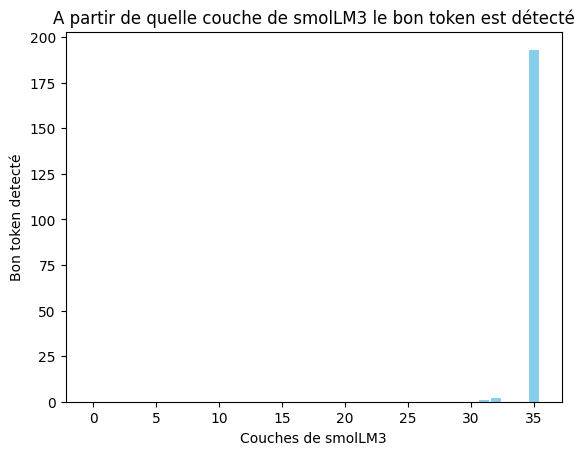

In [26]:
layer_analysis(model, tokenizer, df)